# Torsion Fingerprint Deviation (TFD): RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 8 of the nvMolKit acceleration series.**

[TFD](https://pubs.acs.org/doi/10.1021/ci2002318) compares two conformers by the deviation of their torsion
angles, weighted by their position in the molecule. Like RMSD (Tutorial 7), the all-pairs TFD matrix is
**O(nConfs²)** per molecule and is a common conformer-clustering distance metric. Unlike RMSD, TFD needs no
alignment, so it is purely deterministic.

This notebook compares:

- **RDKit (CPU)** — `TorsionFingerprints.GetTFDMatrix(mol)` per molecule.
- **nvMolKit (GPU)** — `nvmolkit.tfd.GetTFDMatrices(mols)`, all molecules in one launch.

Both use the same defaults (`useWeights=True, maxDev='equal', symmRadius=2, ignoreColinearBonds=True`), so the
values should agree closely.

> RDKit's TFD matrix has no native threaded path, so the `rdkit_16thread` column is a 16-way **multi-process**
> baseline (consistent with Tutorials 6-7). TFD needs torsions, so we keep molecules with several rotatable
> bonds. Run from `examples/tutorials/`.


## 1. Setup and GPU check

In [1]:
import copy
import multiprocessing
import time
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from rdkit.Chem import MolFromSmiles, AddHs, TorsionFingerprints
from rdkit.Chem.Descriptors import NumRotatableBonds
from rdkit.Chem.rdDistGeom import ETKDGv3, EmbedMultipleConfs

import nvmolkit
from nvmolkit.tfd import GetTFDMatrices

RDLogger.DisableLog("rdApp.*")
assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
N_CPU_THREADS = 16   # consistent with tutorials 1-5; here a 16-process CPU baseline
print(f"nvmolkit : {nvmolkit.__version__}")
print(f"torch    : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")

nvmolkit : 0.5.0
torch    : 2.12.0+cu126
GPU      : NVIDIA A100 80GB PCIe


## 2. Parameters

In [2]:
CONFS_PER_MOL = 30
RANDOM_SEED = 42
SIZES = [10, 25, 50]
MIN_HEAVY, MAX_HEAVY = 15, 30
MIN_ROT_BONDS = 3                    # TFD needs torsions to be meaningful
SMI_FILE = "../../benchmarks/data/chembl_10k.smi"
print(f"confs/mol={CONFS_PER_MOL}, pairs/mol={CONFS_PER_MOL*(CONFS_PER_MOL-1)//2}, sizes={SIZES}")

confs/mol=30, pairs/mol=435, sizes=[10, 25, 50]


## 3. Load molecules and embed conformers (once)

We keep normal-sized molecules with at least `MIN_ROT_BONDS` rotatable bonds (so TFD is meaningful) that embed
the full conformer set.

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=10000).iloc[:, 0].tolist()
params = ETKDGv3(); params.randomSeed = RANDOM_SEED

mols_all = []
for s in smis:
    m = MolFromSmiles(s)
    if m is None or not (MIN_HEAVY <= m.GetNumHeavyAtoms() <= MAX_HEAVY):
        continue
    if NumRotatableBonds(m) < MIN_ROT_BONDS:
        continue
    mh = AddHs(m)
    EmbedMultipleConfs(mh, numConfs=CONFS_PER_MOL, params=params)
    if mh.GetNumConformers() == CONFS_PER_MOL:
        mols_all.append(mh)
    if len(mols_all) >= max(SIZES):
        break
SIZES = [n for n in SIZES if n <= len(mols_all)]
print(f"Prepared {len(mols_all)} molecules x {CONFS_PER_MOL} conformers; sweep sizes = {SIZES}")

Prepared 50 molecules x 30 conformers; sweep sizes = [10, 25, 50]


## 4. Define the backends

Both produce the flat lower-triangular TFD vector per molecule; we concatenate across molecules. The 16-way
baseline spreads RDKit's per-molecule loop across worker processes.

In [4]:
def _rdkit_tfd_one(mol):
    return list(TorsionFingerprints.GetTFDMatrix(mol))


def rdkit_tfd(mols):                              # 1 thread (serial)
    return np.concatenate([np.array(_rdkit_tfd_one(m)) for m in mols])


def rdkit_tfd_parallel(mols, workers=N_CPU_THREADS):   # 16-way multi-process
    ctx = multiprocessing.get_context("fork")
    with ProcessPoolExecutor(max_workers=workers, mp_context=ctx) as ex:
        results = list(ex.map(_rdkit_tfd_one, mols))
    return np.concatenate([np.array(r) for r in results])


def nvmolkit_tfd(mols):
    out = GetTFDMatrices(mols, return_type="numpy")
    torch.cuda.synchronize()
    return np.concatenate([np.asarray(x) for x in out])

## 5. Correctness check

TFD is deterministic (no alignment), so the GPU values should match RDKit closely. Small differences can appear
on a few highly symmetric torsions.

In [5]:
sample = mols_all[:max(SIZES)]
rd_t = rdkit_tfd(sample)
nv_t = nvmolkit_tfd(sample)

diff = np.abs(rd_t - nv_t)
print(f"pairs compared : {len(rd_t)}")
print(f"mean |Delta|   : {diff.mean():.5f}")
print(f"median |Delta| : {np.median(diff):.5f}")
print(f"max  |Delta|   : {diff.max():.5f}")
print(f"correlation    : {np.corrcoef(rd_t, nv_t)[0, 1]:.6f}")
print("\n(TFD is in [0, 1]; values agree closely. A few symmetric torsions can differ slightly.)")

pairs compared : 21750
mean |Delta|   : 0.00127
median |Delta| : 0.00002
max  |Delta|   : 0.17740
correlation    : 0.997186

(TFD is in [0, 1]; values agree closely. A few symmetric torsions can differ slightly.)


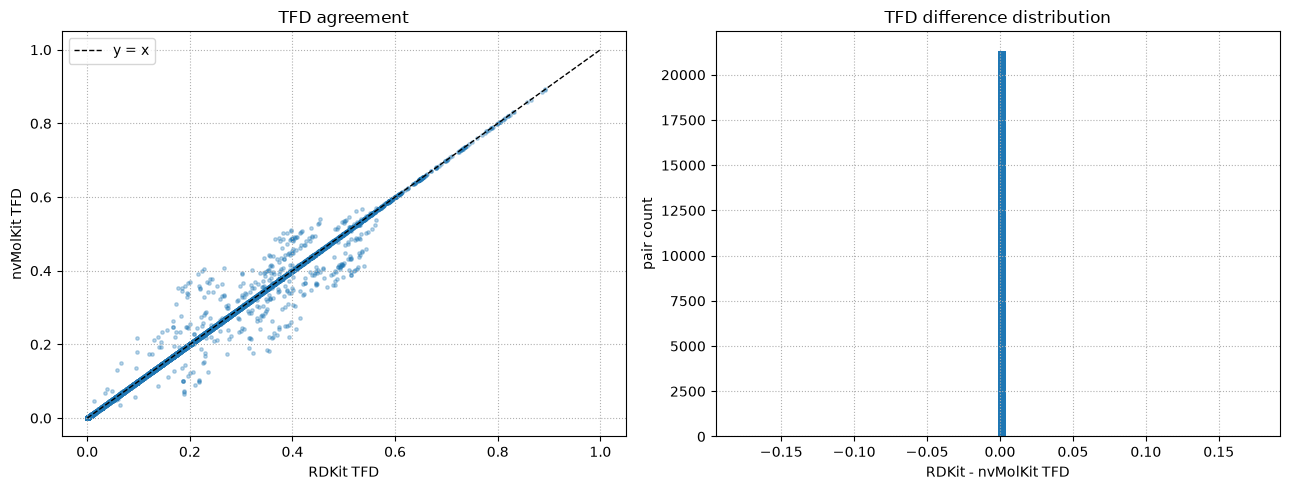

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.scatter(rd_t, nv_t, s=6, alpha=0.3)
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="y = x")
ax1.set_xlabel("RDKit TFD")
ax1.set_ylabel("nvMolKit TFD")
ax1.set_title("TFD agreement")
ax1.legend(); ax1.grid(True, ls=":")

ax2.hist(rd_t - nv_t, bins=60)
ax2.set_xlabel("RDKit - nvMolKit TFD")
ax2.set_ylabel("pair count")
ax2.set_title("TFD difference distribution")
ax2.grid(True, ls=":")
plt.tight_layout(); plt.show()

## 6. Warm up the GPU

In [7]:
_ = nvmolkit_tfd(mols_all[:5])
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

RDKit 1-thread (serial) and 16-thread (16 processes) vs nvMolKit GPU (one batched launch).

In [8]:
def timed(fn, mols):
    t = time.perf_counter()
    fn(mols)
    torch.cuda.synchronize()
    return time.perf_counter() - t


rows = []
for n in SIZES:
    base = mols_all[:n]
    t_rd1 = timed(rdkit_tfd, base)
    t_rdN = timed(rdkit_tfd_parallel, base)
    t_gpu = timed(nvmolkit_tfd, base)
    total_pairs = n * CONFS_PER_MOL * (CONFS_PER_MOL - 1) // 2
    rows.append({
        "n_mols": n,
        "total_pairs": total_pairs,
        "rdkit_1thread_s": t_rd1,
        "rdkit_16thread_s": t_rdN,
        "nvmolkit_gpu_s": t_gpu,
        "gpu_pairs_per_s": total_pairs / t_gpu,
        "speedup_vs_1thread": t_rd1 / t_gpu,
        "speedup_vs_16thread": t_rdN / t_gpu,
    })
    print(f"n={n:4d} | pairs={total_pairs:7d} | RDKit-1t {t_rd1:7.3f}s | "
          f"RDKit-16t {t_rdN:6.3f}s | nvMolKit {t_gpu:6.4f}s | "
          f"speedup {t_rd1/t_gpu:6.1f}x / {t_rdN/t_gpu:5.1f}x")

df = pd.DataFrame(rows)
df

n=  10 | pairs=   4350 | RDKit-1t   0.051s | RDKit-16t  0.167s | nvMolKit 0.0030s | speedup   17.2x /  56.1x


n=  25 | pairs=  10875 | RDKit-1t   0.129s | RDKit-16t  0.152s | nvMolKit 0.0016s | speedup   79.8x /  94.3x


n=  50 | pairs=  21750 | RDKit-1t   0.258s | RDKit-16t  0.185s | nvMolKit 0.0029s | speedup   89.9x /  64.2x


,n_mols,total_pairs,rdkit_1thread_s,rdkit_16thread_s,nvmolkit_gpu_s,gpu_pairs_per_s,speedup_vs_1thread,speedup_vs_16thread
0,10,4350,0.051361,0.167211,0.002982,1.458976e+06,17.226405,56.081918
1,25,10875,0.128879,0.152303,0.001614,6.736783e+06,79.837267,94.347679
2,50,21750,0.258406,0.184536,0.002873,7.569604e+06,89.932514,64.223637


## 8. Plot: runtime and speedup vs number of molecules

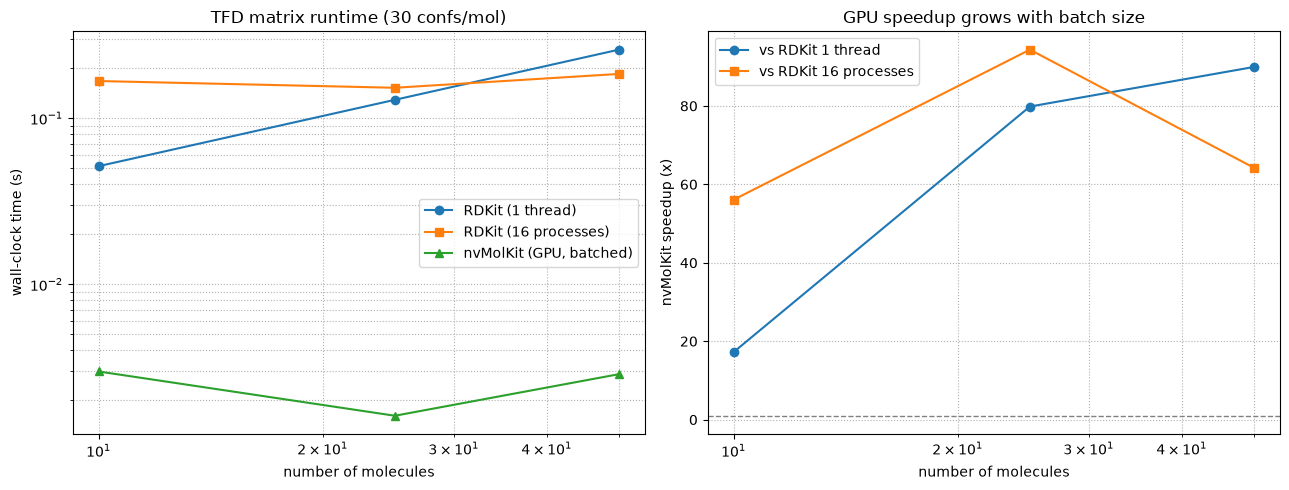

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df["n_mols"], df["rdkit_1thread_s"], "o-", label="RDKit (1 thread)")
ax1.plot(df["n_mols"], df["rdkit_16thread_s"], "s-", label="RDKit (16 processes)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (GPU, batched)")
ax1.set_xlabel("number of molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title(f"TFD matrix runtime ({CONFS_PER_MOL} confs/mol)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup_vs_1thread"], "o-", label="vs RDKit 1 thread")
ax2.plot(df["n_mols"], df["speedup_vs_16thread"], "s-", label="vs RDKit 16 processes")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("GPU speedup grows with batch size")
ax2.set_xscale("log")
ax2.legend(); ax2.grid(True, which="both", ls=":")
plt.tight_layout(); plt.show()

## 9. Takeaways

- **Matches RDKit.** With identical TFD settings the GPU values agree with RDKit closely (correlation ~1.0);
  only a few highly symmetric torsions differ slightly.
- **Batched and fast.** `GetTFDMatrices` computes every molecule's TFD matrix in a single launch, giving a
  several-fold-to-large speedup that grows with the number of molecules.
- **Alignment-free.** Unlike RMSD, TFD compares torsion angles directly - fully deterministic, no Kabsch step.
- **Feeds clustering.** The lower-triangular output is a drop-in distance matrix for Butina clustering
  (Tutorial 9); `return_type='tensor'` keeps results on the GPU to avoid a host round-trip.

**Next:** Tutorial 9 covers Butina clustering.